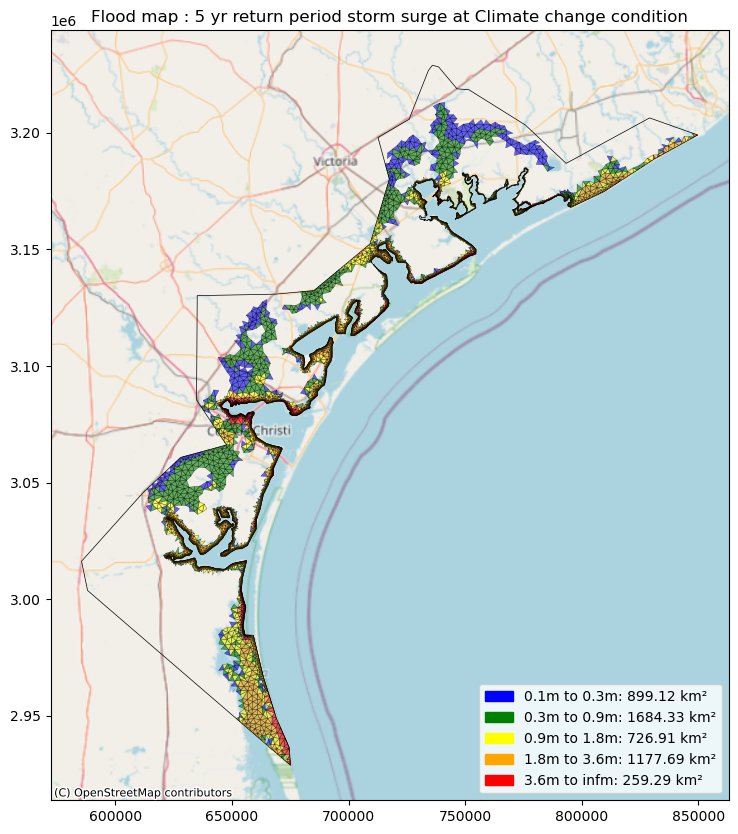

Depth range 0.1m to 0.3m: 899.12 square kilometers
Depth range 0.3m to 0.9m: 1684.33 square kilometers
Depth range 0.9m to 1.8m: 726.91 square kilometers
Depth range 1.8m to 3.6m: 1177.69 square kilometers
Depth range 3.6m to infm: 259.29 square kilometers


In [2]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\5-yr return period storm CC.m21fm - Result Files\5-yr_CC_stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth") 

# Load the shapefile for the land boundary
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)

# Extract geometry information
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges
depth_ranges = [
    (0.1, 0.3),
    (0.3, 0.9),
    (0.9, 1.8),
    (1.8, 3.6),
    (3.6, np.inf)
]

# Colors for plotting
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

for low, high in depth_ranges:
    # Identify elements within the depth range
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    
    flooded_polygons = []
    for elem_idx in flooded_elements:
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons
    flooded_area_gdf = gpd.GeoDataFrame(
        {'geometry': flooded_polygons},
        crs="EPSG:32614"  # UTM Zone 14N
    )
    
    # Clip the polygons with the shapefile boundary
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection')
    
    # Calculate the total area for this depth range
    total_area = flooded_area_clipped.area.sum()
    total_area_by_range.append(total_area / 1e6)  # Convert to square kilometers
    
    flooded_polygons_by_range.append(flooded_area_clipped)

# Plotting with Basemap
fig, ax = plt.subplots(figsize=(10, 10))
land_boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot each range with a different color
for polygons, color in zip(flooded_polygons_by_range, colors):
    if not polygons.empty:  # Plot only if there are polygons in the range
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='black', linewidth=0.3)

# Add basemap
ctx.add_basemap(ax, crs=land_boundary.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=color, label=f'{low}m to {high}m: {area:.2f} km²') 
    for (low, high), color, area in zip(depth_ranges, colors, total_area_by_range)
]
ax.legend(handles=legend_patches, loc='lower right')

plt.title('Flood map : 5 yr return period storm surge at Climate change condition')
plt.show()

# Print the area for each range
for (low, high), area in zip(depth_ranges, total_area_by_range):
    print(f"Depth range {low}m to {high}m: {area:.2f} square kilometers")


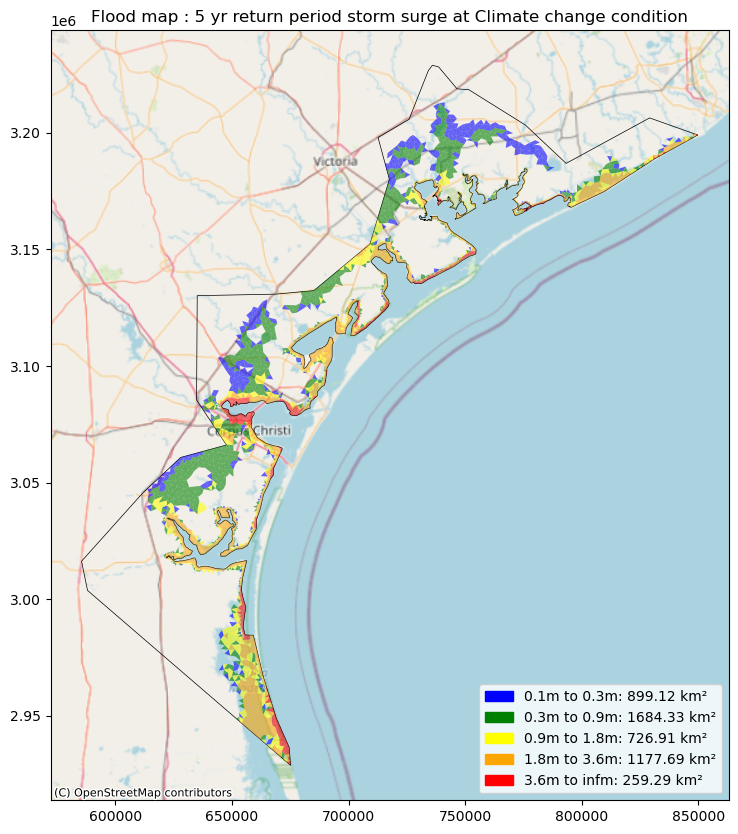

Depth range 0.1m to 0.3m: 899.12 square kilometers
Depth range 0.3m to 0.9m: 1684.33 square kilometers
Depth range 0.9m to 1.8m: 726.91 square kilometers
Depth range 1.8m to 3.6m: 1177.69 square kilometers
Depth range 3.6m to infm: 259.29 square kilometers


In [5]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\5-yr return period storm CC.m21fm - Result Files\5-yr_CC_stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth") 

# Load the shapefile for the land boundary
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)

# Extract geometry information
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges
depth_ranges = [
    (0.1, 0.3),
    (0.3, 0.9),
    (0.9, 1.8),
    (1.8, 3.6),
    (3.6, np.inf)
]

# Colors for plotting
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

for low, high in depth_ranges:
    # Identify elements within the depth range
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    
    flooded_polygons = []
    for elem_idx in flooded_elements:
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons
    flooded_area_gdf = gpd.GeoDataFrame(
        {'geometry': flooded_polygons},
        crs="EPSG:32614"  # UTM Zone 14N
    )
    
    # Clip the polygons with the shapefile boundary
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection')
    
    # Calculate the total area for this depth range
    total_area = flooded_area_clipped.area.sum()
    total_area_by_range.append(total_area / 1e6)  # Convert to square kilometers
    
    flooded_polygons_by_range.append(flooded_area_clipped)

# Plotting with Basemap
fig, ax = plt.subplots(figsize=(10, 10))
land_boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot each range with a different color and set edgecolor='none' to remove mesh visibility
for polygons, color in zip(flooded_polygons_by_range, colors):
    if not polygons.empty:  # Plot only if there are polygons in the range
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='none')  # edgecolor='none' hides the mesh lines

# Add basemap
ctx.add_basemap(ax, crs=land_boundary.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=color, label=f'{low}m to {high}m: {area:.2f} km²') 
    for (low, high), color, area in zip(depth_ranges, colors, total_area_by_range)
]
ax.legend(handles=legend_patches, loc='lower right')

plt.title('Flood map : 5 yr return period storm surge at Climate change condition')
plt.show()

# Print the area for each range
for (low, high), area in zip(depth_ranges, total_area_by_range):
    print(f"Depth range {low}m to {high}m: {area:.2f} square kilometers")


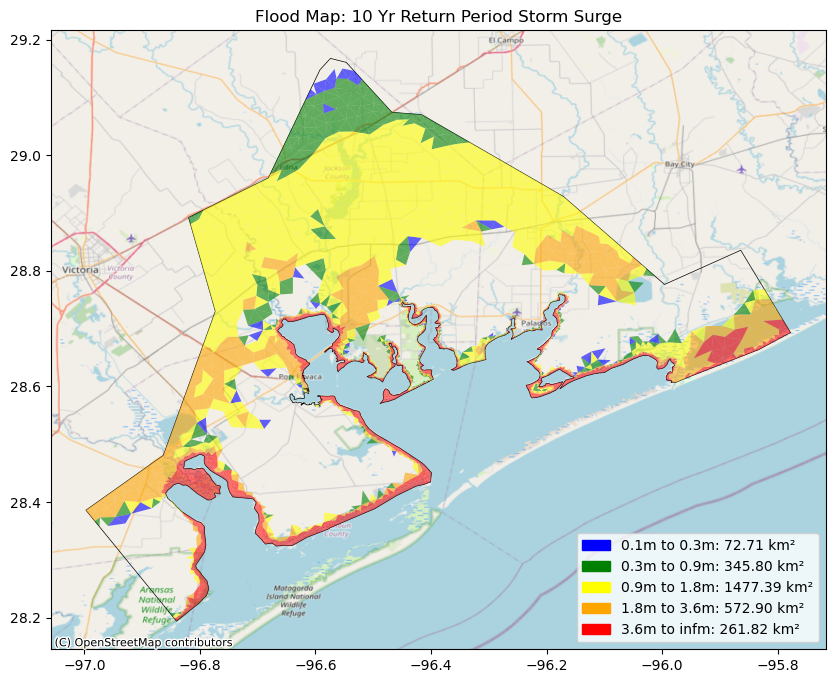

Depth range 0.1m to 0.3m: 72.71 square kilometers
Depth range 0.3m to 0.9m: 345.80 square kilometers
Depth range 0.9m to 1.8m: 1477.39 square kilometers
Depth range 1.8m to 3.6m: 572.90 square kilometers
Depth range 3.6m to infm: 261.82 square kilometers


In [8]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\10-yr return period storm CC.m21fm - Result Files\10-yr_CC_Stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth") 

# Load the shapefile for the land boundary
shapefile_path = r"D:\Phd Research\GIS\Shape\Project_Proposal\study_area_land_Part.zip"
land_boundary = gpd.read_file(shapefile_path)

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges
depth_ranges = [
    (0.1, 0.3),
    (0.3, 0.9),
    (0.9, 1.8),
    (1.8, 3.6),
    (3.6, np.inf)
]

# Colors for plotting
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

# Process each depth range and create polygons
for low, high in depth_ranges:
    # Identify elements within the depth range
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    
    flooded_polygons = []
    for elem_idx in flooded_elements:
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons
    flooded_area_gdf = gpd.GeoDataFrame({'geometry': flooded_polygons}, crs="EPSG:32614")  # UTM Zone 14N
    
    # Clip the polygons with the shapefile boundary
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection')
    
    # Calculate the total area for this depth range
    total_area = flooded_area_clipped.area.sum()
    total_area_by_range.append(total_area / 1e6)  # Convert to square kilometers
    
    flooded_polygons_by_range.append(flooded_area_clipped)

# Reproject everything to Lat-Long (WGS 84, EPSG:4326)
land_boundary_latlong = land_boundary.to_crs(epsg=4326)
flooded_polygons_by_range_latlong = [polygons.to_crs(epsg=4326) for polygons in flooded_polygons_by_range]

# Plotting with Basemap in Lat-Long
fig, ax = plt.subplots(figsize=(10, 10))
land_boundary_latlong.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot each range with a different color
for polygons, color in zip(flooded_polygons_by_range_latlong, colors):
    if not polygons.empty:
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='none')

# Add a Lat-Long basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=color, label=f'{low}m to {high}m: {area:.2f} km²') 
    for (low, high), color, area in zip(depth_ranges, colors, total_area_by_range)
]
ax.legend(handles=legend_patches, loc='lower right')

plt.title('Flood Map: 10 Yr Return Period Storm Surge')
plt.show()

# Print the area for each range
for (low, high), area in zip(depth_ranges, total_area_by_range):
    print(f"Depth range {low}m to {high}m: {area:.2f} square kilometers")


                 County  Total Population  Flood-Affected Population  \
0         Kenedy County             184.0                      190.0   
1        Kleberg County           22288.0                    22962.0   
2      Matagorda County            9798.0                     9904.0   
3         Nueces County          308016.0                   312028.0   
4        Refugio County            2607.0                     2748.0   
5   San Patricio County           53130.0                    59083.0   
6       Victoria County            1087.0                     1126.0   
7        Wharton County              43.0                       44.0   
8        Aransas County           20993.0                    23058.0   
9            Bee County             573.0                      590.0   
10      Brazoria County             385.0                      393.0   
11       Calhoun County           20613.0                    21257.0   
12       Jackson County           11717.0                    119

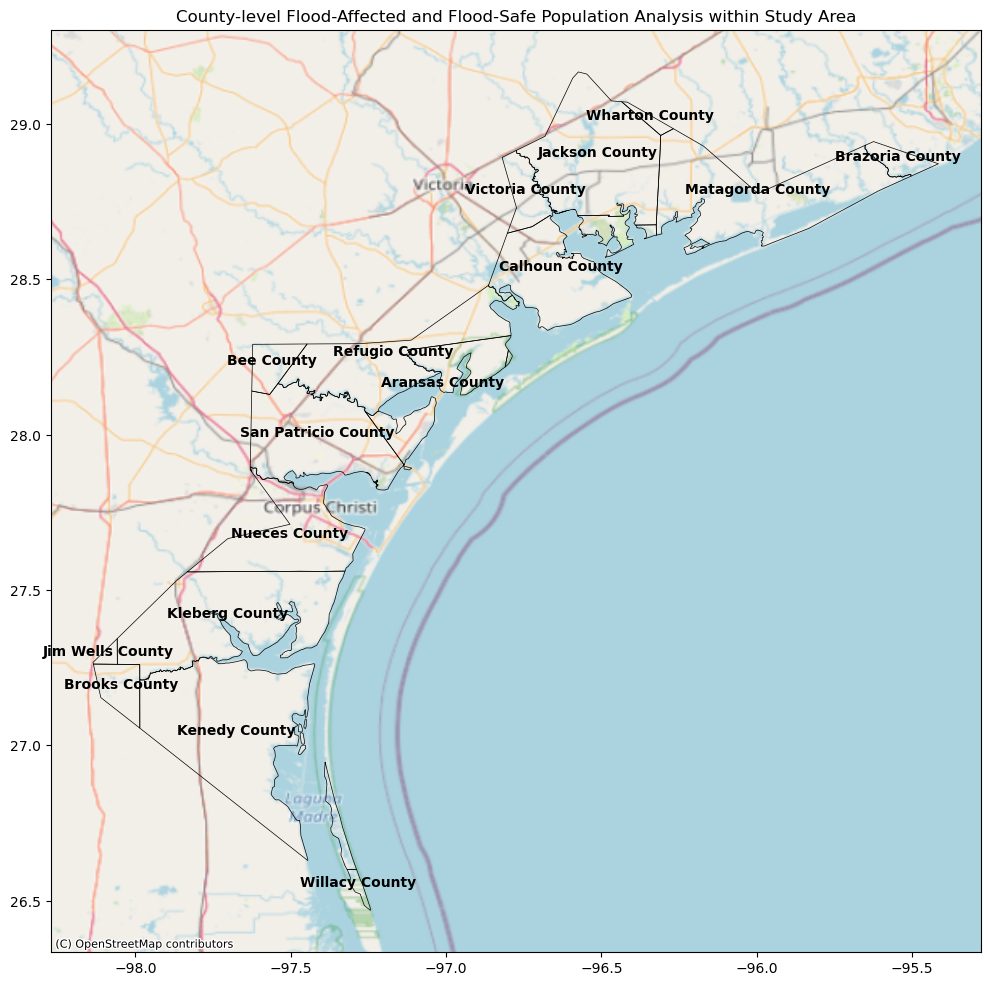

In [12]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\50-yr return period storm CC.m21fm - Result Files\50-yr_CC_coupled_stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth")

# Load the shapefile for the land boundary, SVI data, and counties
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)
svi_path = r"D:\Phd Research\GIS\Shape\fpr_combined_intersection.shp"
svi_data = gpd.read_file(svi_path)
county_shp_path = r"D:\Phd Research\Critical Infrastructure\Shape file\Tx_CntyBndry_Detail_TIGER500k.zip"
county_data = gpd.read_file(county_shp_path).to_crs(32614)

# Ensure 'SVI' and 'Est_Night_' columns in SVI data are numeric, filling non-numeric values with 0
svi_data['SVI'] = pd.to_numeric(svi_data['SVI'], errors='coerce').fillna(0)
svi_data['Est_Night_'] = pd.to_numeric(svi_data['Est_Night_'], errors='coerce').fillna(0)

# Clip counties by land boundary
counties_clipped = gpd.overlay(county_data, land_boundary, how='intersection')

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges and colors for plotting
depth_ranges = [(0.1, 0.3), (0.3, 0.9), (0.9, 1.8), (1.8, 3.6), (3.6, np.inf)]
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists to store analysis results by county
county_names = []
county_populations = []
county_flood_affected_populations = []
county_flood_safe_populations = []
county_avg_svi = []

# Process each county within the clipped counties
for idx, county in counties_clipped.iterrows():
    # Clip SVI data by each county to get relevant population and SVI
    svi_in_county = gpd.overlay(svi_data, gpd.GeoDataFrame([county], crs=county_data.crs), how='intersection')

    # Ensure no negative SVI or Est_Night_ values before calculations
    svi_in_county['SVI'] = svi_in_county['SVI'].clip(lower=0)
    svi_in_county['Est_Night_'] = svi_in_county['Est_Night_'].clip(lower=0)

    # Calculate total population for the county
    county_population = svi_in_county['Est_Night_'].sum()

    # Initialize flood-affected population
    county_flood_affected_population = 0

    # Create a set to keep track of flooded areas already counted to avoid double-counting
    flooded_elements_set = set()

    # Process each depth range and calculate flood-affected population by county
    for low, high in depth_ranges:
        # Identify elements within the depth range
        flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
        
        # Clip flooded area to county boundary
        flooded_polygons = []
        for elem_idx in flooded_elements:
            nodes = element_table[elem_idx]
            coords = node_coordinates[nodes]
            polygon = Polygon(coords)
            flooded_polygons.append(polygon)
        
        # Create a GeoDataFrame for the flooded polygons
        flooded_area_gdf = gpd.GeoDataFrame({'geometry': flooded_polygons}, crs="EPSG:32614")  # UTM Zone 14N
        flooded_area_clipped = gpd.overlay(flooded_area_gdf, gpd.GeoDataFrame([county], crs=county_data.crs), how='intersection')

        # Calculate the total flood-affected population within the county for this range
        flood_vulnerable_population = gpd.overlay(flooded_area_clipped, svi_in_county, how='intersection')
        
        # Ensure no double counting of flooded areas
        for _, row in flood_vulnerable_population.iterrows():
            if row['geometry'] not in flooded_elements_set:
                county_flood_affected_population += row['Est_Night_']
                flooded_elements_set.add(row['geometry'])

    # Calculate flood-safe population
    county_flood_safe_population = county_population - county_flood_affected_population

    # Calculate the weighted SVI for the county
    svi_in_county['Weighted_SVI'] = svi_in_county['SVI'] * svi_in_county['Est_Night_']
    total_weighted_svi = svi_in_county['Weighted_SVI'].sum()
    avg_svi = total_weighted_svi / county_population if county_population > 0 else 0

    # Store results
    county_names.append(county['NAME'])  # Assumes county name field is 'NAME'
    county_populations.append(county_population)
    county_flood_affected_populations.append(county_flood_affected_population)
    county_flood_safe_populations.append(county_flood_safe_population)
    county_avg_svi.append(avg_svi)

# Create a DataFrame to display county-level analysis results
county_analysis_df = pd.DataFrame({
    'County': county_names,
    'Total Population': county_populations,
    'Flood-Affected Population': county_flood_affected_populations,
    'Flood-Safe Population': county_flood_safe_populations,
    'Average SVI': county_avg_svi
})

print(county_analysis_df)

# Optional: Plot county boundaries with flood analysis and add labels for each county
fig, ax = plt.subplots(figsize=(12, 12))
counties_clipped.to_crs(epsg=4326).plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Add a basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

# Add labels for each county, ensuring centroids are in EPSG:4326
for idx, row in counties_clipped.iterrows():
    # Calculate the centroid and reproject it to EPSG:4326 for labeling
    centroid = row['geometry'].centroid
    centroid = gpd.GeoSeries([centroid], crs="EPSG:32614").to_crs("EPSG:4326").iloc[0]
    
    ax.annotate(row['NAME'], (centroid.x, centroid.y), fontsize=10, ha='center', color='black', weight='bold')

plt.title('County-level Flood-Affected and Flood-Safe Population Analysis within Study Area')
plt.show()


                 County  Total Population  Flood-Affected Population  \
0         Kenedy County             184.0                        0.0   
1        Kleberg County           22288.0                        0.0   
2      Matagorda County            9798.0                        0.0   
3         Nueces County          308016.0                        0.0   
4        Refugio County            2607.0                        0.0   
5   San Patricio County           53130.0                        0.0   
6       Victoria County            1087.0                        0.0   
7        Wharton County              43.0                        0.0   
8        Aransas County           20993.0                        0.0   
9            Bee County             573.0                        0.0   
10      Brazoria County             385.0                        0.0   
11       Calhoun County           20613.0                        0.0   
12       Jackson County           11717.0                       

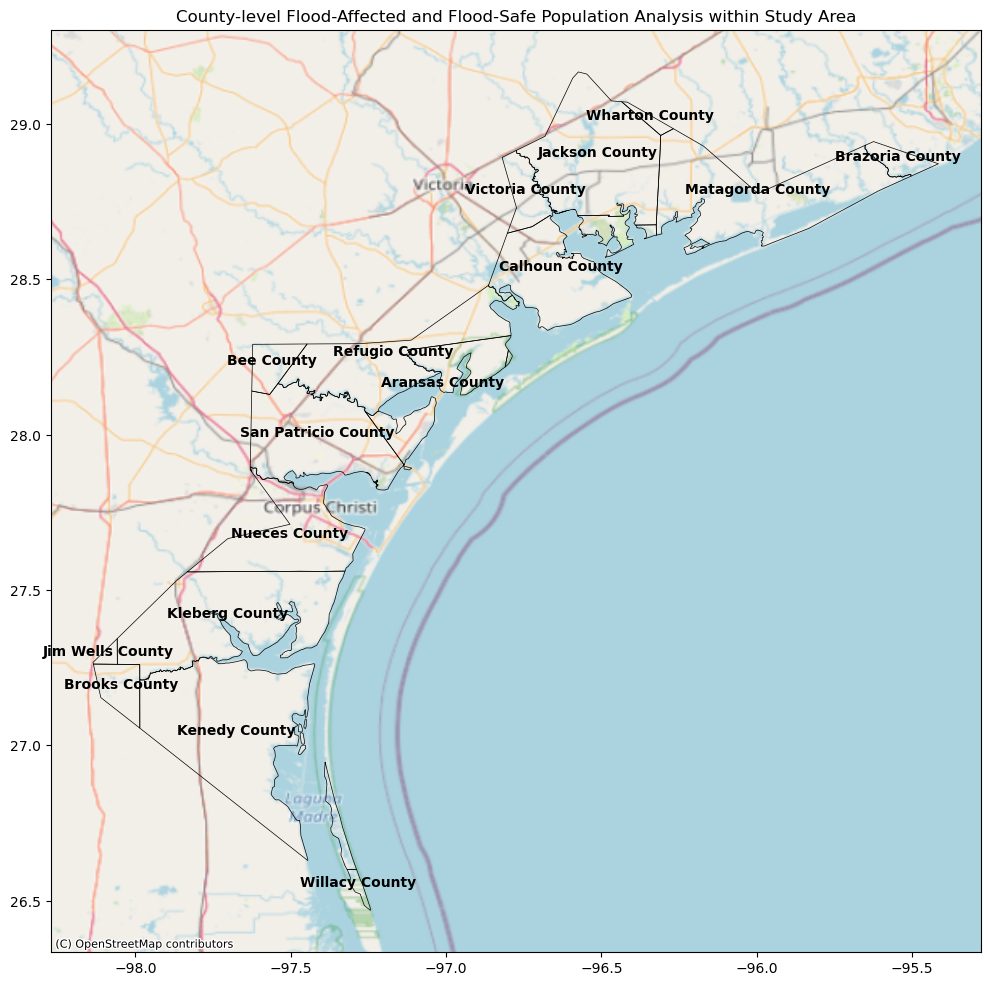

In [13]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\50-yr return period storm CC.m21fm - Result Files\50-yr_CC_coupled_stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth")

# Load the shapefile for the land boundary, SVI data, and counties
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)
svi_path = r"D:\Phd Research\GIS\Shape\fpr_combined_intersection.shp"
svi_data = gpd.read_file(svi_path)
county_shp_path = r"D:\Phd Research\Critical Infrastructure\Shape file\Tx_CntyBndry_Detail_TIGER500k.zip"
county_data = gpd.read_file(county_shp_path).to_crs(32614)

# Ensure 'SVI' and 'Est_Night_' columns in SVI data are numeric, filling non-numeric values with 0
svi_data['SVI'] = pd.to_numeric(svi_data['SVI'], errors='coerce').fillna(0)
svi_data['Est_Night_'] = pd.to_numeric(svi_data['Est_Night_'], errors='coerce').fillna(0)

# Clip counties by land boundary
counties_clipped = gpd.overlay(county_data, land_boundary, how='intersection')

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges and colors for plotting
depth_ranges = [(0.1, 0.3), (0.3, 0.9), (0.9, 1.8), (1.8, 3.6), (3.6, np.inf)]
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists to store analysis results by county
county_names = []
county_populations = []
county_flood_affected_populations = []
county_flood_safe_populations = []
county_avg_svi = []

# Process each county within the clipped counties
for idx, county in counties_clipped.iterrows():
    # Clip SVI data by each county to get relevant population and SVI
    svi_in_county = gpd.overlay(svi_data, gpd.GeoDataFrame([county], crs=county_data.crs), how='intersection')

    # Ensure no negative SVI or Est_Night_ values before calculations
    svi_in_county['SVI'] = svi_in_county['SVI'].clip(lower=0)
    svi_in_county['Est_Night_'] = svi_in_county['Est_Night_'].clip(lower=0)

    # Calculate total population for the county
    county_population = svi_in_county['Est_Night_'].sum()

    # Initialize flood-affected population
    county_flood_affected_population = 0

    # Create a set to keep track of flooded areas already counted to avoid double-counting
    flooded_elements_set = set()

    # Process each depth range and calculate flood-affected population by county
    for low, high in depth_ranges:
        # Identify elements within the depth range
        flooded_elements = np.where((water_depth > low) & (water_depth <= high))[0]
        
        # Clip flooded area to county boundary
        flooded_polygons = []
        for elem_idx in flooded_elements:
            nodes = element_table[elem_idx]
            coords = node_coordinates[nodes]
            polygon = Polygon(coords)
            flooded_polygons.append(polygon)
        
        # Create a GeoDataFrame for the flooded polygons
        flooded_area_gdf = gpd.GeoDataFrame({'geometry': flooded_polygons}, crs="EPSG:32614")  # UTM Zone 14N
        flooded_area_clipped = gpd.overlay(flooded_area_gdf, gpd.GeoDataFrame([county], crs=county_data.crs), how='intersection')

        # Calculate the total flood-affected population within the county for this range
        flood_vulnerable_population = gpd.overlay(flooded_area_clipped, svi_in_county, how='intersection')
        
        # Sum only the new population for each flooded area in the current depth range
        county_flood_affected_population += flood_vulnerable_population['Est_Night_'].sum()

    # Calculate flood-safe population (ensuring non-negative result)
    county_flood_safe_population = max(0, county_population - county_flood_affected_population)

    # Calculate the weighted SVI for the county
    svi_in_county['Weighted_SVI'] = svi_in_county['SVI'] * svi_in_county['Est_Night_']
    total_weighted_svi = svi_in_county['Weighted_SVI'].sum()
    avg_svi = total_weighted_svi / county_population if county_population > 0 else 0

    # Store results
    county_names.append(county['NAME'])  # Assumes county name field is 'NAME'
    county_populations.append(county_population)
    county_flood_affected_populations.append(county_flood_affected_population)
    county_flood_safe_populations.append(county_flood_safe_population)
    county_avg_svi.append(avg_svi)

# Create a DataFrame to display county-level analysis results
county_analysis_df = pd.DataFrame({
    'County': county_names,
    'Total Population': county_populations,
    'Flood-Affected Population': county_flood_affected_populations,
    'Flood-Safe Population': county_flood_safe_populations,
    'Average SVI': county_avg_svi
})

print(county_analysis_df)

# Optional: Plot county boundaries with flood analysis and add labels for each county
fig, ax = plt.subplots(figsize=(12, 12))
counties_clipped.to_crs(epsg=4326).plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Add a basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

# Add labels for each county, ensuring centroids are in EPSG:4326
for idx, row in counties_clipped.iterrows():
    # Calculate the centroid and reproject it to EPSG:4326 for labeling
    centroid = row['geometry'].centroid
    centroid = gpd.GeoSeries([centroid], crs="EPSG:32614").to_crs("EPSG:4326").iloc[0]
    
    ax.annotate(row['NAME'], (centroid.x, centroid.y), fontsize=10, ha='center', color='black', weight='bold')

plt.title('County-level Flood-Affected and Flood-Safe Population Analysis within Study Area')
plt.show()


                 County  Total Population  Flood-Affected Population  \
0         Kenedy County             184.0                      187.0   
1        Kleberg County           22288.0                    21313.0   
2      Matagorda County            9798.0                     5708.0   
3         Nueces County          308016.0                   261624.0   
4        Refugio County            2607.0                     2559.0   
5   San Patricio County           53130.0                    56330.0   
6       Victoria County            1087.0                     1126.0   
7        Wharton County              43.0                       44.0   
8        Aransas County           20993.0                    21930.0   
9            Bee County             573.0                      590.0   
10      Brazoria County             385.0                      393.0   
11       Calhoun County           20613.0                    18104.0   
12       Jackson County           11717.0                    116

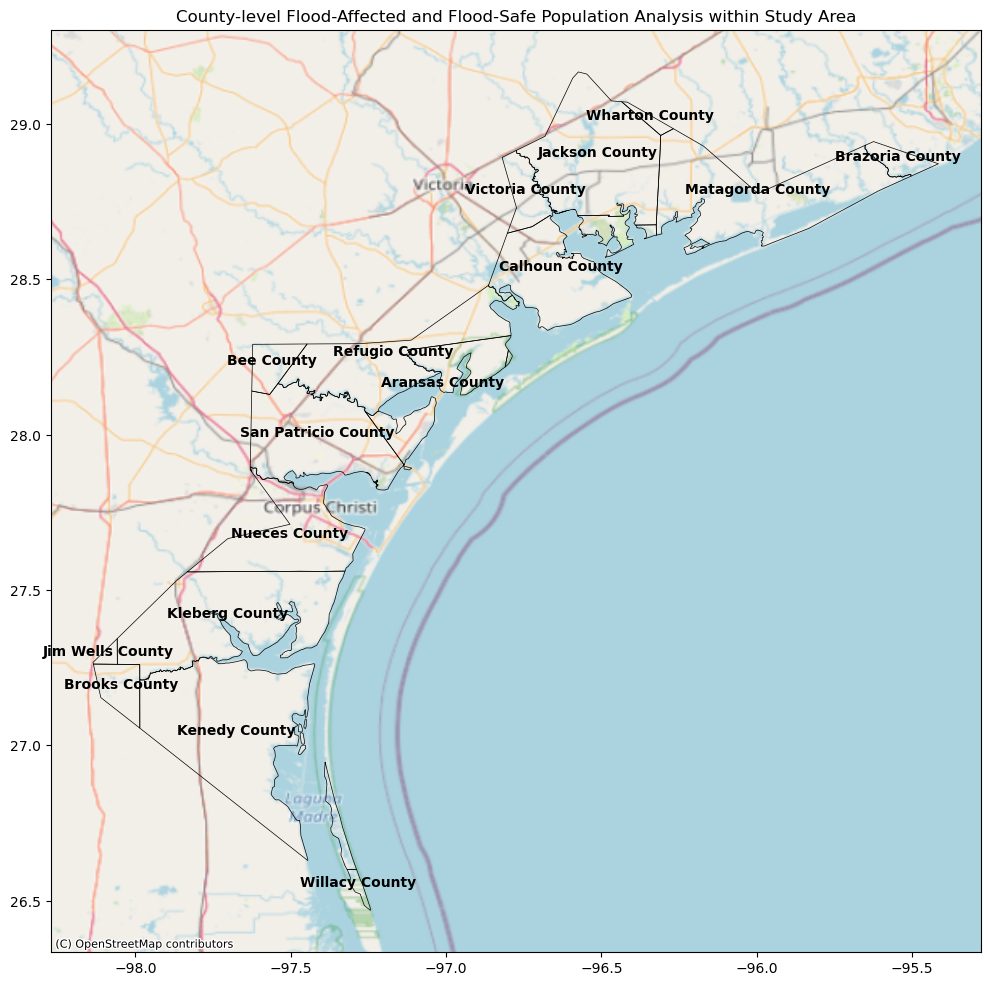

In [20]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\20-yr return period storm CC.m21fm - Result Files\20-yr_CC_Stat_coupled.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth")

# Load the shapefile for the land boundary, SVI data, and counties
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)
svi_path = r"D:\Phd Research\GIS\Shape\fpr_combined_intersection.shp"
svi_data = gpd.read_file(svi_path)
county_shp_path = r"D:\Phd Research\Critical Infrastructure\Shape file\Tx_CntyBndry_Detail_TIGER500k.zip"
county_data = gpd.read_file(county_shp_path).to_crs(32614)

# Ensure 'SVI' and 'Est_Night_' columns in SVI data are numeric, filling non-numeric values with 0
svi_data['SVI'] = pd.to_numeric(svi_data['SVI'], errors='coerce').fillna(0)
svi_data['Est_Night_'] = pd.to_numeric(svi_data['Est_Night_'], errors='coerce').fillna(0)

# Clip counties by land boundary
counties_clipped = gpd.overlay(county_data, land_boundary, how='intersection')

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges and colors for plotting
depth_ranges = [(0.1, 0.3), (0.3, 0.9), (0.9, 1.8), (1.8, 3.6), (3.6, np.inf)]
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists to store analysis results by county
county_names = []
county_populations = []
county_flood_affected_populations = []
county_flood_safe_populations = []
county_avg_svi = []

# Process each county within the clipped counties
for idx, county in counties_clipped.iterrows():
    # Clip SVI data by each county to get relevant population and SVI
    svi_in_county = gpd.overlay(svi_data, gpd.GeoDataFrame([county], crs=county_data.crs), how='intersection')

    # Calculate total population for the county
    county_population = svi_in_county['Est_Night_'].sum()

    # Initialize flood-affected population
    county_flood_affected_population = 0

    # Clip flooded area by county boundary and calculate flood-affected population
    flooded_elements = []
    for low, high in depth_ranges:
        flooded_elements_idx = np.where((water_depth > low) & (water_depth <= high))[1]
        
        # Create polygons for flooded elements
        for elem_idx in flooded_elements_idx:
            nodes = element_table[elem_idx]
            coords = node_coordinates[nodes]
            polygon = Polygon(coords)
            flooded_elements.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons and clip by county
    flooded_area_gdf = gpd.GeoDataFrame({'geometry': flooded_elements}, crs="EPSG:32614")
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, gpd.GeoDataFrame([county], crs=county_data.crs), how='intersection')

    # Calculate the total flood-affected population within the county
    flood_vulnerable_population = gpd.overlay(flooded_area_clipped, svi_in_county, how='intersection')
    county_flood_affected_population = flood_vulnerable_population['Est_Night_'].sum()

    # Calculate flood-safe population
    county_flood_safe_population = county_population - county_flood_affected_population

    # Calculate the weighted SVI for the county
    svi_in_county['Weighted_SVI'] = svi_in_county['SVI'] * svi_in_county['Est_Night_']
    total_weighted_svi = svi_in_county['Weighted_SVI'].sum()
    avg_svi = total_weighted_svi / county_population if county_population > 0 else 0

    # Store results
    county_names.append(county['NAME'])  # Assumes county name field is 'NAME'
    county_populations.append(county_population)
    county_flood_affected_populations.append(county_flood_affected_population)
    county_flood_safe_populations.append(county_flood_safe_population)
    county_avg_svi.append(avg_svi)

# Create a DataFrame to display county-level analysis results
county_analysis_df = pd.DataFrame({
    'County': county_names,
    'Total Population': county_populations,
    'Flood-Affected Population': county_flood_affected_populations,
    'Flood-Safe Population': county_flood_safe_populations,
    'Average SVI': county_avg_svi
})

print(county_analysis_df)

# Optional: Plot county boundaries with flood analysis and add labels for each county
fig, ax = plt.subplots(figsize=(12, 12))
counties_clipped.to_crs(epsg=4326).plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Add a basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

# Add labels for each county, ensuring centroids are in EPSG:4326
for idx, row in counties_clipped.iterrows():
    # Calculate the centroid and reproject it to EPSG:4326 for labeling
    centroid = row['geometry'].centroid
    centroid = gpd.GeoSeries([centroid], crs="EPSG:32614").to_crs("EPSG:4326").iloc[0]
    
    ax.annotate(row['NAME'], (centroid.x, centroid.y), fontsize=10, ha='center', color='black', weight='bold')

plt.title('County-level Flood-Affected and Flood-Safe Population Analysis within Study Area')
plt.show()


                 County  Total Population  Flood-Affected Population  \
0         Kenedy County             184.0                      190.0   
1        Kleberg County           22288.0                    22962.0   
2      Matagorda County            9798.0                     9904.0   
3         Nueces County          308016.0                   312028.0   
4        Refugio County            2607.0                     2753.0   
5   San Patricio County           53130.0                    59083.0   
6       Victoria County            1087.0                     1126.0   
7        Wharton County              43.0                       44.0   
8        Aransas County           20993.0                    23058.0   
9            Bee County             573.0                      590.0   
10      Brazoria County             385.0                      393.0   
11       Calhoun County           20613.0                    21435.0   
12       Jackson County           11717.0                    119

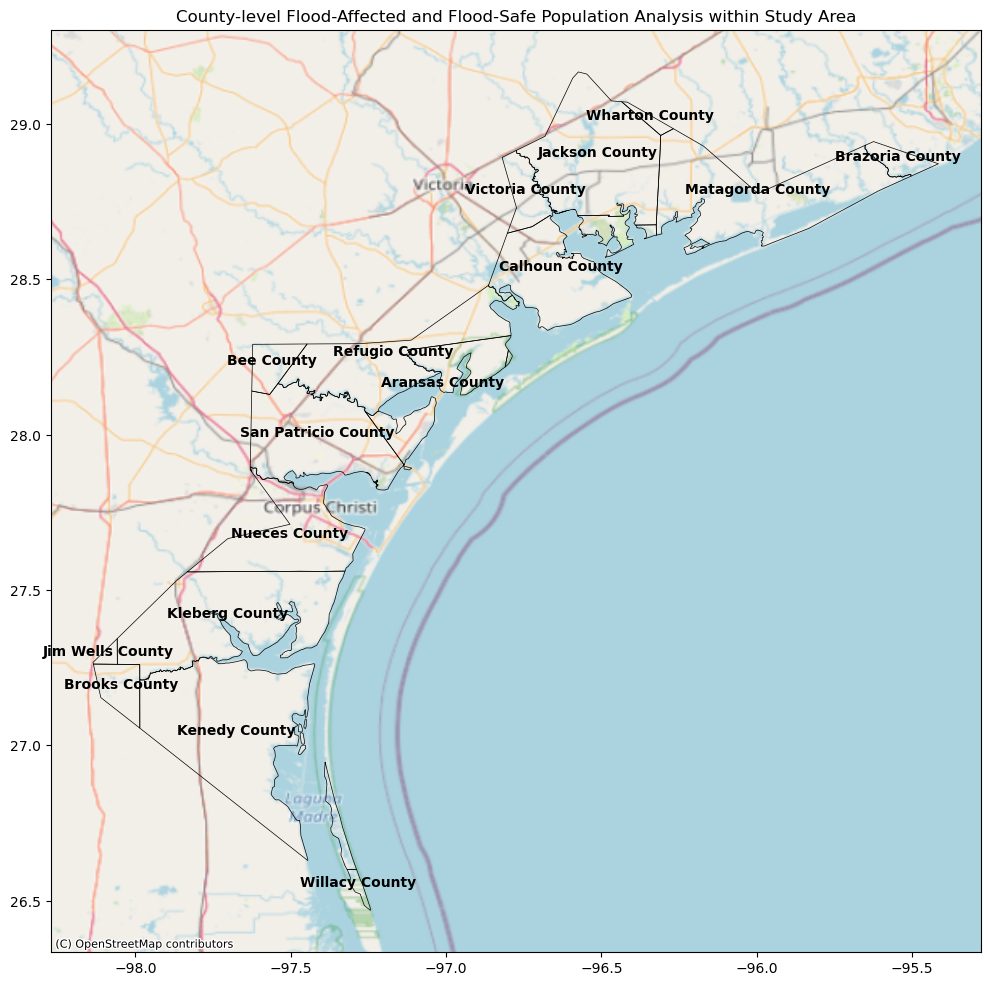

In [33]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\50-yr return period storm CC.m21fm - Result Files\50-yr_CC_coupled_stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth")

# Load the shapefile for the land boundary, SVI data, and counties
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)
svi_path = r"D:\Phd Research\GIS\Shape\fpr_combined_intersection.shp"
svi_data = gpd.read_file(svi_path)
county_shp_path = r"D:\Phd Research\Critical Infrastructure\Shape file\Tx_CntyBndry_Detail_TIGER500k.zip"
county_data = gpd.read_file(county_shp_path).to_crs(32614)

# Ensure 'SVI' and 'Est_Night_' columns in SVI data are numeric, filling non-numeric values with 0
svi_data['SVI'] = pd.to_numeric(svi_data['SVI'], errors='coerce').fillna(0)
svi_data['Est_Night_'] = pd.to_numeric(svi_data['Est_Night_'], errors='coerce').fillna(0)

# Clip counties by land boundary
counties_clipped = gpd.overlay(county_data, land_boundary, how='intersection')

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges and colors for plotting
depth_ranges = [(0.1, 0.3), (0.3, 0.9), (0.9, 1.8), (1.8, 3.6), (3.6, np.inf)]
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists to store analysis results by county
county_names = []
county_populations = []
county_flood_affected_populations = []
county_flood_safe_populations = []
county_avg_svi = []

# Process each county within the clipped counties
for idx, county in counties_clipped.iterrows():
    # Clip SVI data by each county to get relevant population and SVI
    svi_in_county = gpd.overlay(svi_data, gpd.GeoDataFrame([county], crs=county_data.crs), how='intersection')

    # Calculate total population for the county
    county_population = svi_in_county['Est_Night_'].sum()

    # Initialize flood-affected population
    county_flood_affected_population = 0

    # Clip flooded area by county boundary and calculate flood-affected population
    flooded_elements = []
    for low, high in depth_ranges:
        flooded_elements_idx = np.where((water_depth > low) & (water_depth <= high))[1]
        
        # Create polygons for flooded elements
        for elem_idx in flooded_elements_idx:
            nodes = element_table[elem_idx]
            coords = node_coordinates[nodes]
            polygon = Polygon(coords)
            flooded_elements.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons and clip by county
    flooded_area_gdf = gpd.GeoDataFrame({'geometry': flooded_elements}, crs="EPSG:32614")
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, gpd.GeoDataFrame([county], crs=county_data.crs), how='intersection')

    # Calculate the total flood-affected population within the county
    flood_vulnerable_population = gpd.overlay(flooded_area_clipped, svi_in_county, how='intersection')
    county_flood_affected_population = flood_vulnerable_population['Est_Night_'].sum()

    # Calculate flood-safe population
    county_flood_safe_population = county_population - county_flood_affected_population

    # Calculate the weighted SVI for the county
    svi_in_county['Weighted_SVI'] = svi_in_county['SVI'] * svi_in_county['Est_Night_']
    total_weighted_svi = svi_in_county['Weighted_SVI'].sum()
    avg_svi = total_weighted_svi / county_population if county_population > 0 else 0

    # Store results
    county_names.append(county['NAME'])  # Assumes county name field is 'NAME'
    county_populations.append(county_population)
    county_flood_affected_populations.append(county_flood_affected_population)
    county_flood_safe_populations.append(county_flood_safe_population)
    county_avg_svi.append(avg_svi)

# Create a DataFrame to display county-level analysis results
county_analysis_df = pd.DataFrame({
    'County': county_names,
    'Total Population': county_populations,
    'Flood-Affected Population': county_flood_affected_populations,
    'Flood-Safe Population': county_flood_safe_populations,
    'Average SVI': county_avg_svi
})

print(county_analysis_df)

# Optional: Plot county boundaries with flood analysis and add labels for each county
fig, ax = plt.subplots(figsize=(12, 12))
counties_clipped.to_crs(epsg=4326).plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Add a basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

# Add labels for each county, ensuring centroids are in EPSG:4326
for idx, row in counties_clipped.iterrows():
    # Calculate the centroid and reproject it to EPSG:4326 for labeling
    centroid = row['geometry'].centroid
    centroid = gpd.GeoSeries([centroid], crs="EPSG:32614").to_crs("EPSG:4326").iloc[0]
    
    ax.annotate(row['NAME'], (centroid.x, centroid.y), fontsize=10, ha='center', color='black', weight='bold')

plt.title('County-level Flood-Affected and Flood-Safe Population Analysis within Study Area')
plt.show()

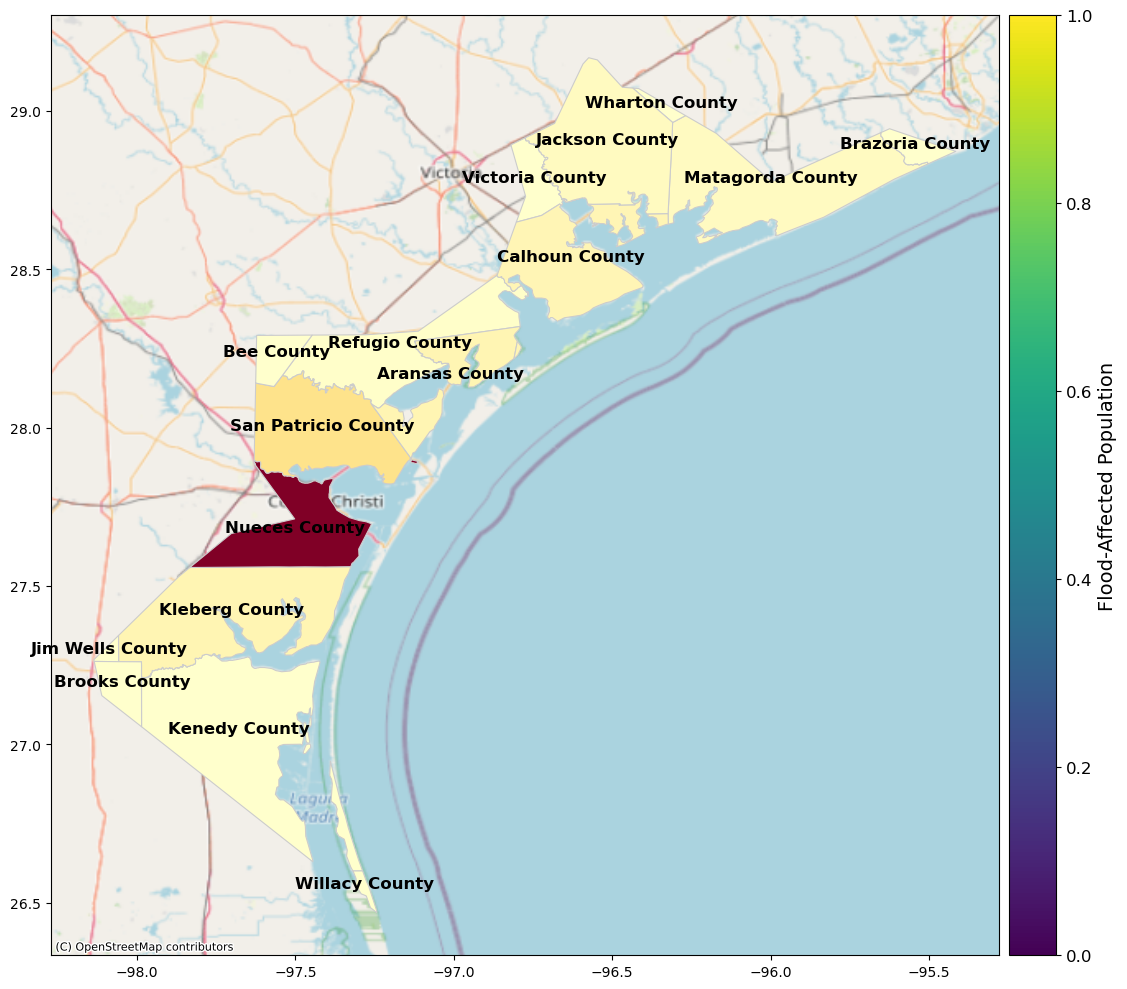

                 County  Total Population  Flood-Affected Population  \
0         Kenedy County             184.0                      190.0   
1        Kleberg County           22288.0                    22962.0   
2      Matagorda County            9798.0                     9904.0   
3         Nueces County          308016.0                   312028.0   
4        Refugio County            2607.0                     2753.0   
5   San Patricio County           53130.0                    59083.0   
6       Victoria County            1087.0                     1126.0   
7        Wharton County              43.0                       44.0   
8        Aransas County           20993.0                    23058.0   
9            Bee County             573.0                      590.0   
10      Brazoria County             385.0                      393.0   
11       Calhoun County           20613.0                    21435.0   
12       Jackson County           11717.0                    119

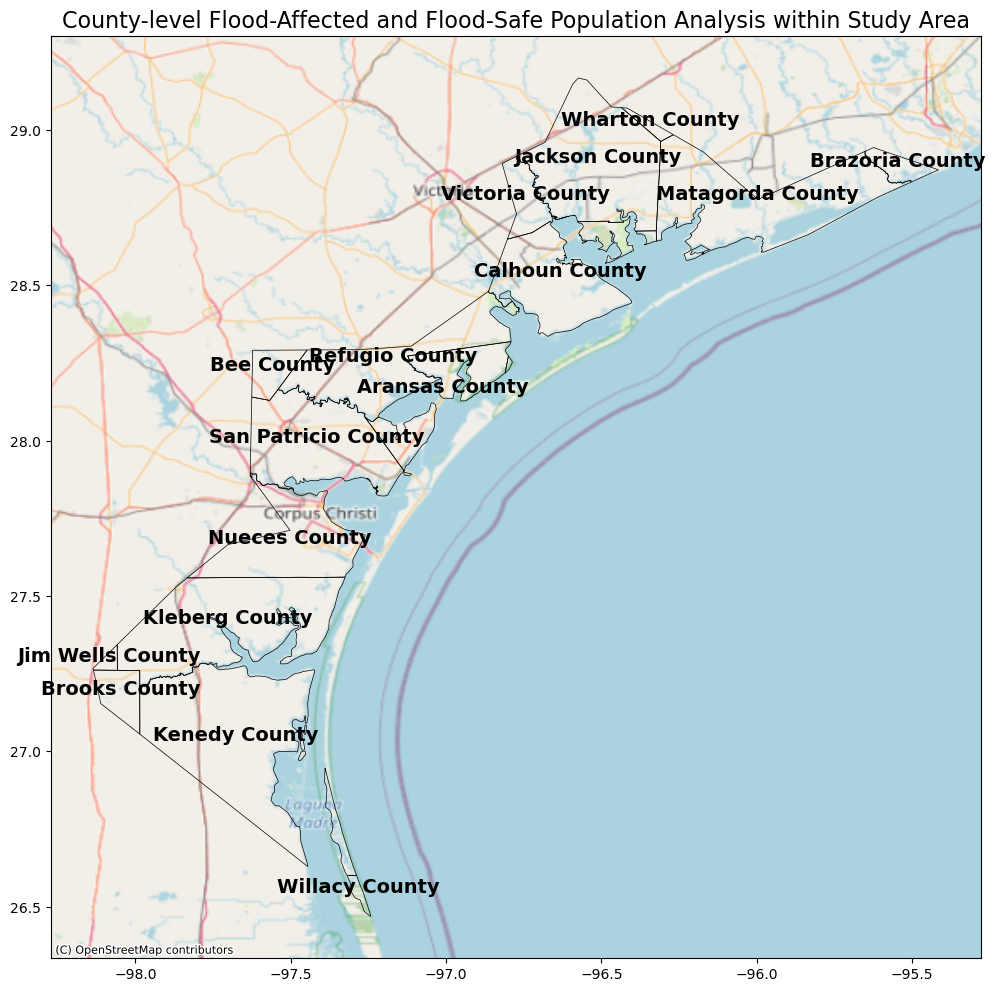

In [36]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\50-yr return period storm CC.m21fm - Result Files\50-yr_CC_coupled_stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth")

# Load the shapefile for the land boundary, SVI data, and counties
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)
svi_path = r"D:\Phd Research\GIS\Shape\fpr_combined_intersection.shp"
svi_data = gpd.read_file(svi_path)
county_shp_path = r"D:\Phd Research\Critical Infrastructure\Shape file\Tx_CntyBndry_Detail_TIGER500k.zip"
county_data = gpd.read_file(county_shp_path).to_crs(32614)

# Ensure 'SVI' and 'Est_Night_' columns in SVI data are numeric, filling non-numeric values with 0
svi_data['SVI'] = pd.to_numeric(svi_data['SVI'], errors='coerce').fillna(0)
svi_data['Est_Night_'] = pd.to_numeric(svi_data['Est_Night_'], errors='coerce').fillna(0)

# Clip counties by land boundary
counties_clipped = gpd.overlay(county_data, land_boundary, how='intersection')

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges and colors for plotting
depth_ranges = [(0.1, 0.3), (0.3, 0.9), (0.9, 1.8), (1.8, 3.6), (3.6, np.inf)]
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists to store analysis results by county
county_names = []
county_populations = []
county_flood_affected_populations = []
county_flood_safe_populations = []
county_avg_svi = []

# Process each county within the clipped counties
for idx, county in counties_clipped.iterrows():
    # Clip SVI data by each county to get relevant population and SVI
    svi_in_county = gpd.overlay(svi_data, gpd.GeoDataFrame([county], crs=county_data.crs), how='intersection')

    # Calculate total population for the county
    county_population = svi_in_county['Est_Night_'].sum()

    # Initialize flood-affected population list
    county_flood_affected_population = 0

    # Clip flooded area by county boundary and calculate flood-affected population
    flooded_elements = []
    for low, high in depth_ranges:
        flooded_elements_idx = np.where((water_depth > low) & (water_depth <= high))[1]
        
        # Create polygons for flooded elements
        for elem_idx in flooded_elements_idx:
            nodes = element_table[elem_idx]
            coords = node_coordinates[nodes]
            polygon = Polygon(coords)
            flooded_elements.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons and clip by county
    flooded_area_gdf = gpd.GeoDataFrame({'geometry': flooded_elements}, crs="EPSG:32614")
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, gpd.GeoDataFrame([county], crs=county_data.crs), how='intersection')

    # Calculate the total flood-affected population within the county
    flood_vulnerable_population = gpd.overlay(flooded_area_clipped, svi_in_county, how='intersection')
    county_flood_affected_population = flood_vulnerable_population['Est_Night_'].sum()

    # Append the flood-affected population for this county
    county_flood_affected_populations.append(county_flood_affected_population)

    # Calculate flood-safe population
    county_flood_safe_population = county_population - county_flood_affected_population

    # Calculate the weighted SVI for the county
    svi_in_county['Weighted_SVI'] = svi_in_county['SVI'] * svi_in_county['Est_Night_']
    total_weighted_svi = svi_in_county['Weighted_SVI'].sum()
    avg_svi = total_weighted_svi / county_population if county_population > 0 else 0

    # Store results
    county_names.append(county['NAME'])  # Assumes county name field is 'NAME'
    county_populations.append(county_population)
    county_flood_safe_populations.append(county_flood_safe_population)
    county_avg_svi.append(avg_svi)

# Create a DataFrame to display county-level analysis results
county_analysis_df = pd.DataFrame({
    'County': county_names,
    'Total Population': county_populations,
    'Flood-Affected Population': county_flood_affected_populations,
    'Flood-Safe Population': county_flood_safe_populations,
    'Average SVI': county_avg_svi
})

print(county_analysis_df)

# Optional: Plot county boundaries with flood analysis and add labels for each county
fig, ax = plt.subplots(figsize=(12, 12))
counties_clipped.to_crs(epsg=4326).plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Add a basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

# Add labels for each county, ensuring centroids are in EPSG:4326
for idx, row in counties_clipped.iterrows():
    # Calculate the centroid and reproject it to EPSG:4326 for labeling
    centroid = row['geometry'].centroid
    centroid = gpd.GeoSeries([centroid], crs="EPSG:32614").to_crs("EPSG:4326").iloc[0]
    
    ax.annotate(row['NAME'], (centroid.x, centroid.y), fontsize=14, ha='center', color='black', weight='bold')

plt.title('County-level Flood-Affected and Flood-Safe Population Analysis within Study Area', fontsize=16)
plt.show()


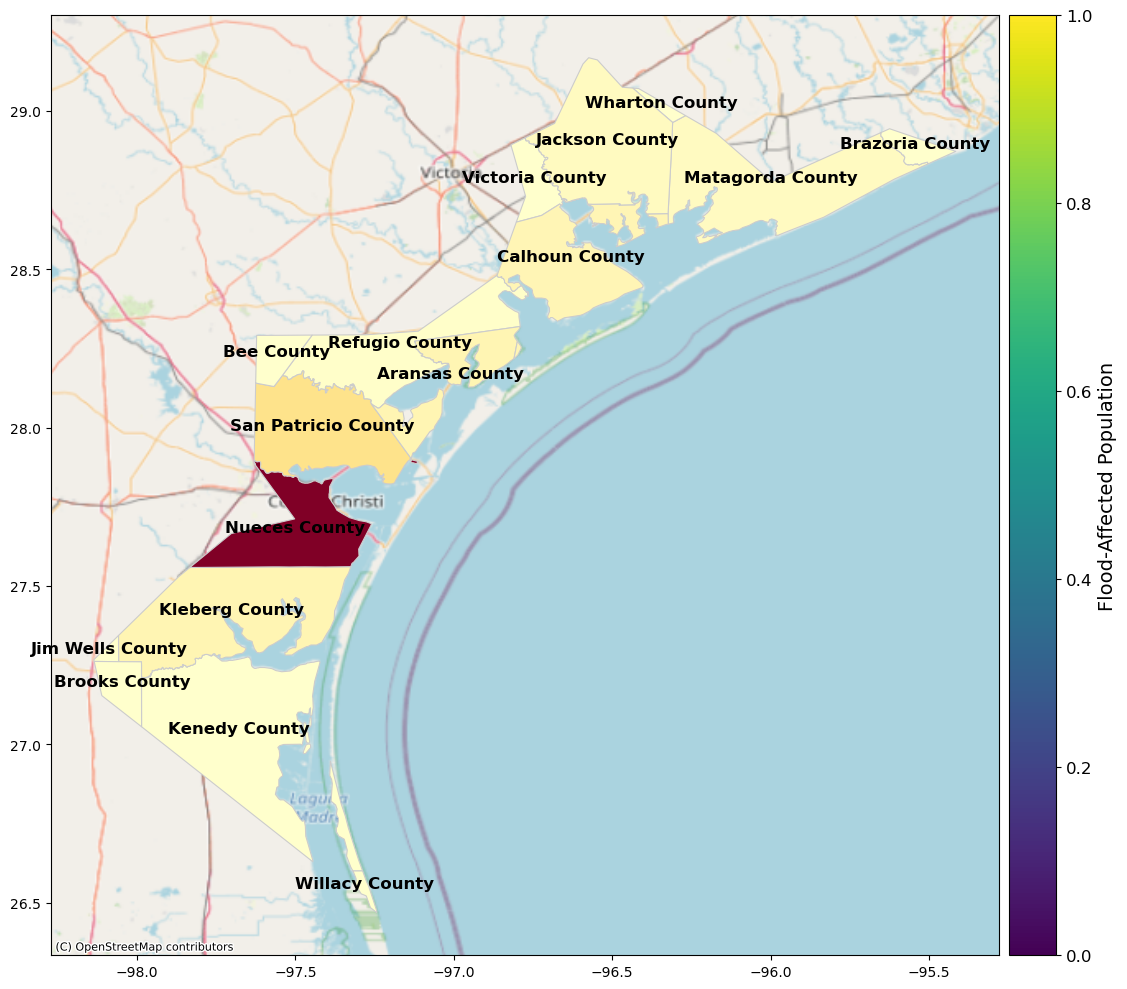

In [38]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Load necessary files
county_shp_path = r"D:\Phd Research\Critical Infrastructure\Shape file\Tx_CntyBndry_Detail_TIGER500k.zip"
land_boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Load and reproject shapefiles
county_data = gpd.read_file(county_shp_path).to_crs(32614)
land_boundary = gpd.read_file(land_boundary_path).to_crs(32614)

# Clip counties by the study area (land boundary)
counties_clipped = gpd.overlay(county_data, land_boundary, how='intersection')

# Ensure the 'county_analysis_df' is defined and contains the necessary 'County' and 'Flood-Affected Population' columns
# county_analysis_df = pd.read_csv('path_to_flood_affected_population_data.csv') # Load your data if necessary

# Merge clipped counties with flood-affected population data
county_flood_map = counties_clipped.merge(county_analysis_df, left_on='NAME', right_on='County')

# Reproject to WGS 84 (EPSG:4326) for compatibility with basemap
county_flood_map = county_flood_map.to_crs(epsg=4326)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))

# Create a color map for flood-affected population
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

# Plot the counties with flood-affected population data
county_flood_map.plot(column='Flood-Affected Population', cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True, 
                      cax=cax, legend_kwds={'label': "Flood-Affected Population", 'orientation': "vertical"})

# Add a basemap
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)

# Add labels for each county (centroids)
for idx, row in county_flood_map.iterrows():
    centroid = row['geometry'].centroid
    ax.annotate(row['NAME'], (centroid.x, centroid.y), fontsize=12, ha='center', color='black', weight='bold')

# Adjust color bar properties manually for font size
cbar = fig.colorbar(cax.collections[0], cax=cax)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Flood-Affected Population", fontsize=14)

# Title and layout adjustments
plt.tight_layout()
plt.show()


                 County  Total Population  Flood-Affected Population  \
0         Kenedy County             184.0                      190.0   
1        Kleberg County           22288.0                    22962.0   
2      Matagorda County            9798.0                     9904.0   
3         Nueces County          308016.0                   312028.0   
4        Refugio County            2607.0                     2753.0   
5   San Patricio County           53130.0                    59083.0   
6       Victoria County            1087.0                     1126.0   
7        Wharton County              43.0                       44.0   
8        Aransas County           20993.0                    23058.0   
9            Bee County             573.0                      590.0   
10      Brazoria County             385.0                      393.0   
11       Calhoun County           20613.0                    21435.0   
12       Jackson County           11717.0                    119

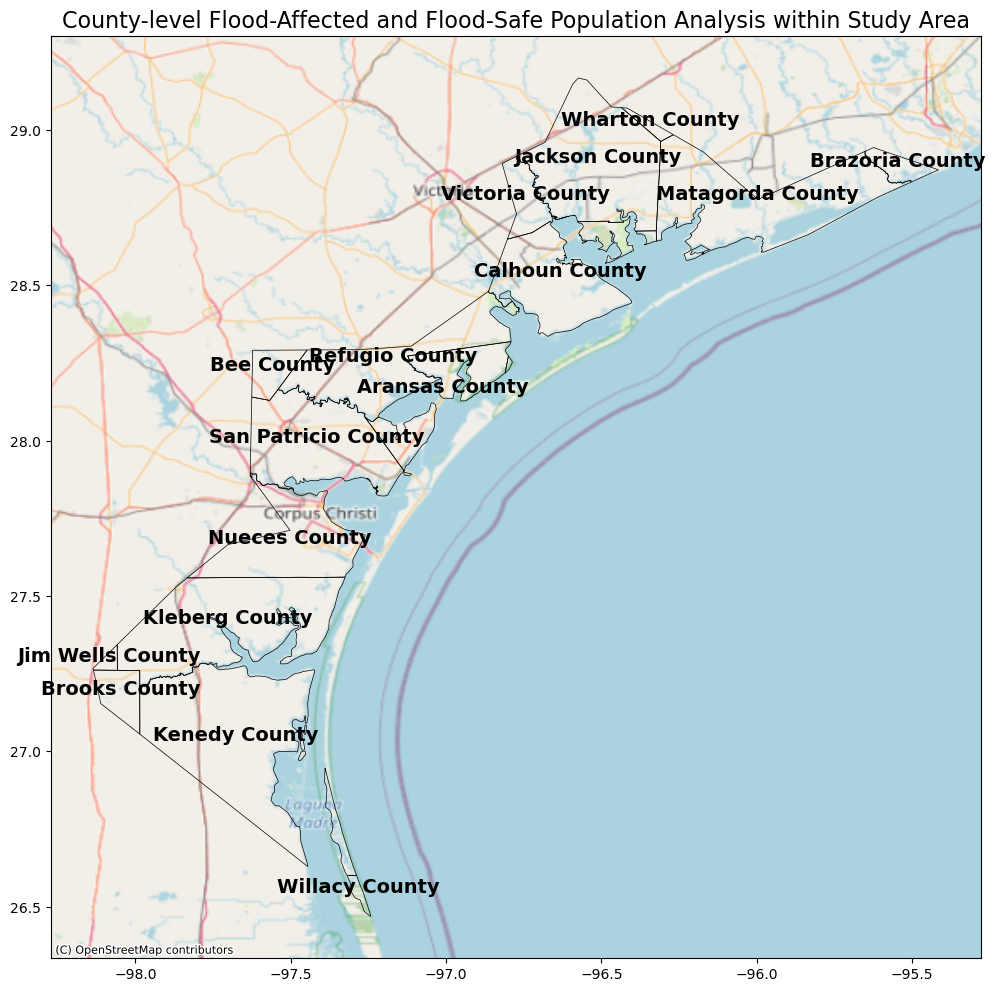

In [39]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\50-yr return period storm CC.m21fm - Result Files\50-yr_CC_coupled_stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth")

# Load the shapefile for the land boundary, SVI data, and counties
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)
svi_path = r"D:\Phd Research\GIS\Shape\fpr_combined_intersection.shp"
svi_data = gpd.read_file(svi_path)
county_shp_path = r"D:\Phd Research\Critical Infrastructure\Shape file\Tx_CntyBndry_Detail_TIGER500k.zip"
county_data = gpd.read_file(county_shp_path).to_crs(32614)

# Ensure 'SVI' and 'Est_Night_' columns in SVI data are numeric, filling non-numeric values with 0
svi_data['SVI'] = pd.to_numeric(svi_data['SVI'], errors='coerce').fillna(0)
svi_data['Est_Night_'] = pd.to_numeric(svi_data['Est_Night_'], errors='coerce').fillna(0)

# Clip counties by land boundary
counties_clipped = gpd.overlay(county_data, land_boundary, how='intersection')

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges and colors for plotting
depth_ranges = [(0.1, 0.3), (0.3, 0.9), (0.9, 1.8), (1.8, 3.6), (3.6, np.inf)]
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists to store analysis results by county
county_names = []
county_populations = []
county_flood_affected_populations = []
county_flood_safe_populations = []
county_avg_svi = []

# Process each county within the clipped counties
for idx, county in counties_clipped.iterrows():
    # Clip SVI data by each county to get relevant population and SVI
    svi_in_county = gpd.overlay(svi_data, gpd.GeoDataFrame([county], crs=county_data.crs), how='intersection')

    # Calculate total population for the county
    county_population = svi_in_county['Est_Night_'].sum()

    # Initialize flood-affected population list
    county_flood_affected_population = 0

    # Clip flooded area by county boundary and calculate flood-affected population
    flooded_elements = []
    for low, high in depth_ranges:
        flooded_elements_idx = np.where((water_depth > low) & (water_depth <= high))[1]
        
        # Create polygons for flooded elements
        for elem_idx in flooded_elements_idx:
            nodes = element_table[elem_idx]
            coords = node_coordinates[nodes]
            polygon = Polygon(coords)
            flooded_elements.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons and clip by county
    flooded_area_gdf = gpd.GeoDataFrame({'geometry': flooded_elements}, crs="EPSG:32614")
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, gpd.GeoDataFrame([county], crs=county_data.crs), how='intersection')

    # Calculate the total flood-affected population within the county
    flood_vulnerable_population = gpd.overlay(flooded_area_clipped, svi_in_county, how='intersection')
    county_flood_affected_population = flood_vulnerable_population['Est_Night_'].sum()

    # Append the flood-affected population for this county
    county_flood_affected_populations.append(county_flood_affected_population)

    # Calculate flood-safe population
    county_flood_safe_population = county_population - county_flood_affected_population

    # Calculate the weighted SVI for the county
    svi_in_county['Weighted_SVI'] = svi_in_county['SVI'] * svi_in_county['Est_Night_']
    total_weighted_svi = svi_in_county['Weighted_SVI'].sum()
    avg_svi = total_weighted_svi / county_population if county_population > 0 else 0

    # Store results
    county_names.append(county['NAME'])  # Assumes county name field is 'NAME'
    county_populations.append(county_population)
    county_flood_safe_populations.append(county_flood_safe_population)
    county_avg_svi.append(avg_svi)

# Create a DataFrame to display county-level analysis results
county_analysis_df = pd.DataFrame({
    'County': county_names,
    'Total Population': county_populations,
    'Flood-Affected Population': county_flood_affected_populations,
    'Flood-Safe Population': county_flood_safe_populations,
    'Average SVI': county_avg_svi
})

print(county_analysis_df)

# Optional: Plot county boundaries with flood analysis and add labels for each county
fig, ax = plt.subplots(figsize=(12, 12))
counties_clipped.to_crs(epsg=4326).plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Add a basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

# Add labels for each county, ensuring centroids are in EPSG:4326
for idx, row in counties_clipped.iterrows():
    # Calculate the centroid and reproject it to EPSG:4326 for labeling
    centroid = row['geometry'].centroid
    centroid = gpd.GeoSeries([centroid], crs="EPSG:32614").to_crs("EPSG:4326").iloc[0]
    
    ax.annotate(row['NAME'], (centroid.x, centroid.y), fontsize=14, ha='center', color='black', weight='bold')

plt.title('County-level Flood-Affected and Flood-Safe Population Analysis within Study Area', fontsize=16)
plt.show()
